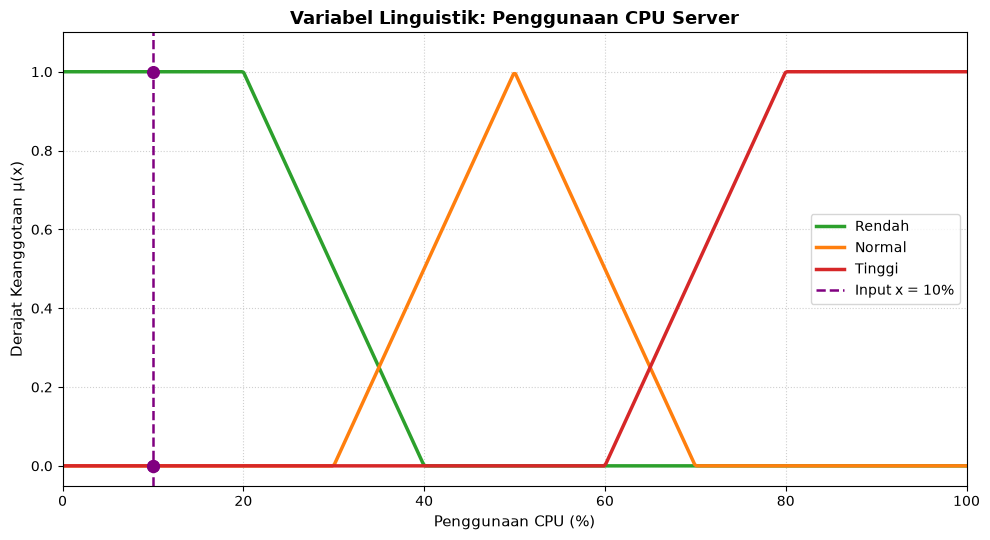

Hasil Fuzzifikasi untuk x = 10 %:
 - Rendah  : 1.0
 - Normal  : 0.0
 - Tinggi  : 0.0


In [4]:
import numpy as np
import matplotlib.pyplot as plt

#DEFINISI FUNGSI KEANGGOTAAN LINGUISTIK

def mf_rendah(x):
    """Fungsi bahu kiri untuk label Rendah"""
    kondisi = [
        x <= 20.0,
        (x > 20.0) & (x < 40.0),
        x >= 40.0
    ]
    pilihan = [
        1.0,
        (40.0 - x) / (40.0 - 20.0),
        0.0
    ]
    return np.select(kondisi, pilihan)


def mf_normal(x):
    """Fungsi segitiga untuk label Normal"""
    kondisi = [
        (x <= 30.0) | (x >= 70.0),
        (x > 30.0) & (x <= 50.0),
        (x > 50.0) & (x < 70.0)
    ]
    pilihan = [
        0.0,
        (x - 30.0) / (50.0 - 30.0),
        (70.0 - x) / (70.0 - 50.0)
    ]
    return np.select(kondisi, pilihan)


def mf_tinggi(x):
    """Fungsi bahu kanan untuk label Tinggi"""
    kondisi = [
        x <= 60.0,
        (x > 60.0) & (x < 80.0),
        x >= 80.0
    ]
    pilihan = [
        0.0,
        (x - 60.0) / (80.0 - 60.0),
        1.0
    ]
    return np.select(kondisi, pilihan)


#DEFINISI STRUKTUR VARIABEL LINGUISTIK

variabel_penggunaan_cpu = {
    "nama": "Penggunaan CPU Server",
    "satuan": "%",
    "semesta": (0.0, 100.0),
    "label": {
        "Rendah": mf_rendah,
        "Normal": mf_normal,
        "Tinggi": mf_tinggi
    }
}


#FUNGSI FUZZIFIKASI INPUT TUNGGAL

def fuzzifikasi(nilai_crisp, variabel):
    """
    Melakukan pemetaan nilai crisp ke semua derajat
    label linguistik.
    """
    hasil = {}

    u_min, u_max = variabel["semesta"]

    if not (u_min <= nilai_crisp <= u_max):
        raise ValueError(
            f"Input {nilai_crisp} di luar semesta [{u_min}, {u_max}]"
        )

    for nama_label, fungsi_mf in variabel["label"].items():
        derajat = float(
            fungsi_mf(np.array([nilai_crisp]))[0]
        )
        hasil[nama_label] = round(derajat, 4)

    return hasil

#PENGUJIAN DAN VISUALISASI

x_semesta = np.linspace(0.0, 100.0, 500)

y_rendah = mf_rendah(x_semesta)
y_normal = mf_normal(x_semesta)
y_tinggi = mf_tinggi(x_semesta)

plt.figure(figsize=(10, 5.5))

plt.plot(
    x_semesta,
    y_rendah,
    label='Rendah',
    color='#2ca02c',
    linewidth=2.5
)

plt.plot(
    x_semesta,
    y_normal,
    label='Normal',
    color='#ff7f0e',
    linewidth=2.5
)

plt.plot(
    x_semesta,
    y_tinggi,
    label='Tinggi',
    color='#d62728',
    linewidth=2.5
)


# Simulasi input x = 10% CPU
x_uji = 10
derajat_uji = fuzzifikasi(x_uji,variabel_penggunaan_cpu)

plt.axvline(
    x=x_uji,
    color='purple',
    linestyle='--',
    linewidth=1.8,
    label=f'Input x = {x_uji}%'
)

plt.scatter(
    [
        x_uji,
        x_uji,
        x_uji
    ],
    [
        derajat_uji['Rendah'],
        derajat_uji['Normal'],
        derajat_uji['Tinggi']
    ],
    color='purple',
    s=70,
    zorder=5
)


plt.title(
    f'Variabel Linguistik: '
    f'{variabel_penggunaan_cpu["nama"]}',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel(
    f'Penggunaan CPU ({variabel_penggunaan_cpu["satuan"]})',
    fontsize=11
)

plt.ylabel(
    'Derajat Keanggotaan μ(x)',
    fontsize=11
)

plt.ylim(-0.05, 1.1)

plt.xlim(0, 100)

plt.grid(
    True,
    linestyle=':',
    alpha=0.6
)

plt.legend(
    loc='center right',
    fontsize=10
)

plt.tight_layout()

# Simpan dan tampilkan grafik
plt.savefig(
    'variabel_linguistik_penggunaan_cpu.png',
    dpi=300
)

plt.show()

#TAMPILKAN HASIL FUZZIFIKASI

print(
    f"Hasil Fuzzifikasi untuk x = "
    f"{x_uji} {variabel_penggunaan_cpu['satuan']}:"
)

for label, deg in derajat_uji.items():
    print(f" - {label:<8}: {deg}")